**Z-SCORE FOR NORMAL DISTRIBUTION**

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
df=pd.read_csv('placement.csv')

In [26]:
df.shape

(1000, 3)

In [28]:
df.sample(5)

,cgpa,placement_exam_marks,placed
865,6.77,16.0,0
309,7.46,31.0,1
438,7.31,7.0,0
22,6.76,54.0,1
110,6.96,31.0,0


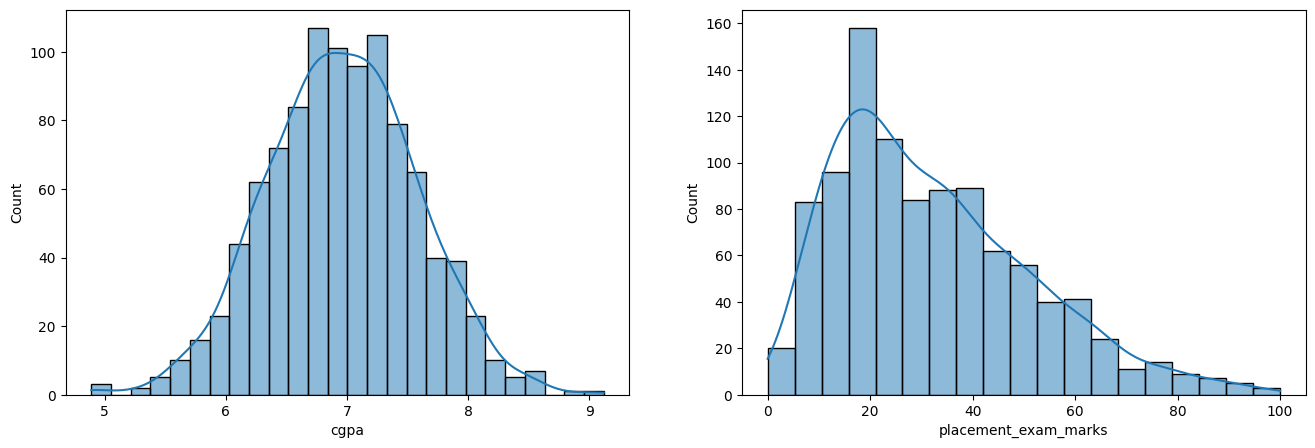

In [32]:
plt.figure(figsize=(16,5))
plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True,fill=True)
plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True)
plt.show()

In [44]:
df['placement_exam_marks'].skew()     #right skewed

0.8356419499466834

In [46]:
df['cgpa'].skew()                    #normal distribution

-0.014529938929314918

In [48]:
print(df['cgpa'].mean())
print(df['cgpa'].std())
print(df['cgpa'].min())
print(df['cgpa'].max())

6.96124
0.6158978751323894
4.89
9.12


In [50]:
 #__________TRIMMING_________
df[(df['cgpa']>df['cgpa'].mean()+3*df['cgpa'].std()) | (df['cgpa']>df['cgpa'].mean()-3*df['cgpa'].std())]

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0
...,...,...,...
993,6.73,21.0,1
994,6.48,63.0,0
995,8.87,44.0,1
996,9.12,65.0,1


In [52]:
# Calculating the Zscore
df['cgpa_zscore']=(df['cgpa']-df['cgpa'].mean())/df['cgpa'].std()

In [54]:
df.head()

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.19,26.0,1,0.371425
1,7.46,38.0,1,0.809810
2,7.54,40.0,1,0.939701
3,6.42,8.0,1,-0.878782
4,7.23,17.0,0,0.436371


In [56]:
df[(df['cgpa_zscore']>3) | (df['cgpa_zscore']<-3)]

,cgpa,placement_exam_marks,placed,cgpa_zscore
485,4.92,44.0,1,-3.314251
995,8.87,44.0,1,3.099150
996,9.12,65.0,1,3.505062
997,4.89,34.0,0,-3.362960
999,4.90,10.0,1,-3.346724


In [58]:
#_____CAPPING______
upper_limit=df['cgpa'].mean()+3*df['cgpa'].std()
lower_limit=df['cgpa'].mean()-3*df['cgpa'].std()

In [60]:
print(upper_limit)
print(lower_limit)

8.808933625397168
5.113546374602832


In [62]:
df['cgpa']=np.where(df['cgpa']>upper_limit,upper_limit,np.where(df['cgpa']<lower_limit,lower_limit,df['cgpa']))

In [66]:
df.shape

(1000, 4)

In [68]:
df['cgpa'].describe()

count    1000.000000
mean        6.961499
std         0.612688
min         5.113546
25%         6.550000
50%         6.960000
75%         7.370000
max         8.808934
Name: cgpa, dtype: float64

**IQR METHOD**

In [75]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: ylabel='placement_exam_marks'>

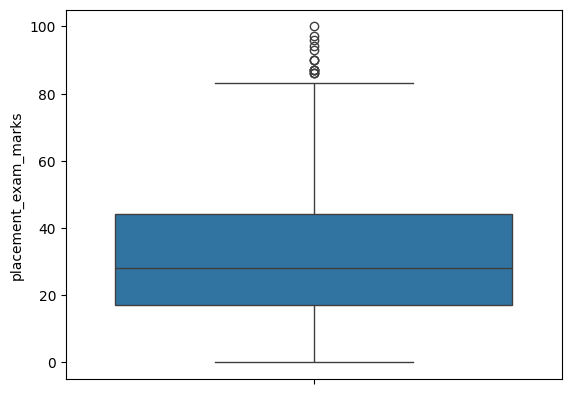

In [77]:
sns.boxplot(df['placement_exam_marks'])

In [87]:
#Finding the IQR
percentile25=df['placement_exam_marks'].quantile(0.25)
percentile75=df['placement_exam_marks'].quantile(0.75)

In [89]:
print(percentile25)
print(percentile75)

17.0
44.0


In [91]:
iqr=percentile75-percentile25

In [93]:
iqr

27.0

In [99]:
ul=percentile75+1.5*iqr
ll=percentile25-1.5*iqr

In [131]:
#______TRIMMING_______
neww_df=df[df['placement_exam_marks']<ul]
neww_df

,cgpa,placement_exam_marks,placed,cgpa_zscore
0,7.190000,26.0,1,0.371425
1,7.460000,38.0,1,0.809810
2,7.540000,40.0,1,0.939701
3,6.420000,8.0,1,-0.878782
4,7.230000,17.0,0,0.436371
...,...,...,...,...
995,8.808934,44.0,1,3.099150
996,8.808934,65.0,1,3.505062
997,5.113546,34.0,0,-3.362960
998,8.620000,46.0,1,2.693239


In [133]:
df[df['placement_exam_marks']<ll]

,cgpa,placement_exam_marks,placed,cgpa_zscore


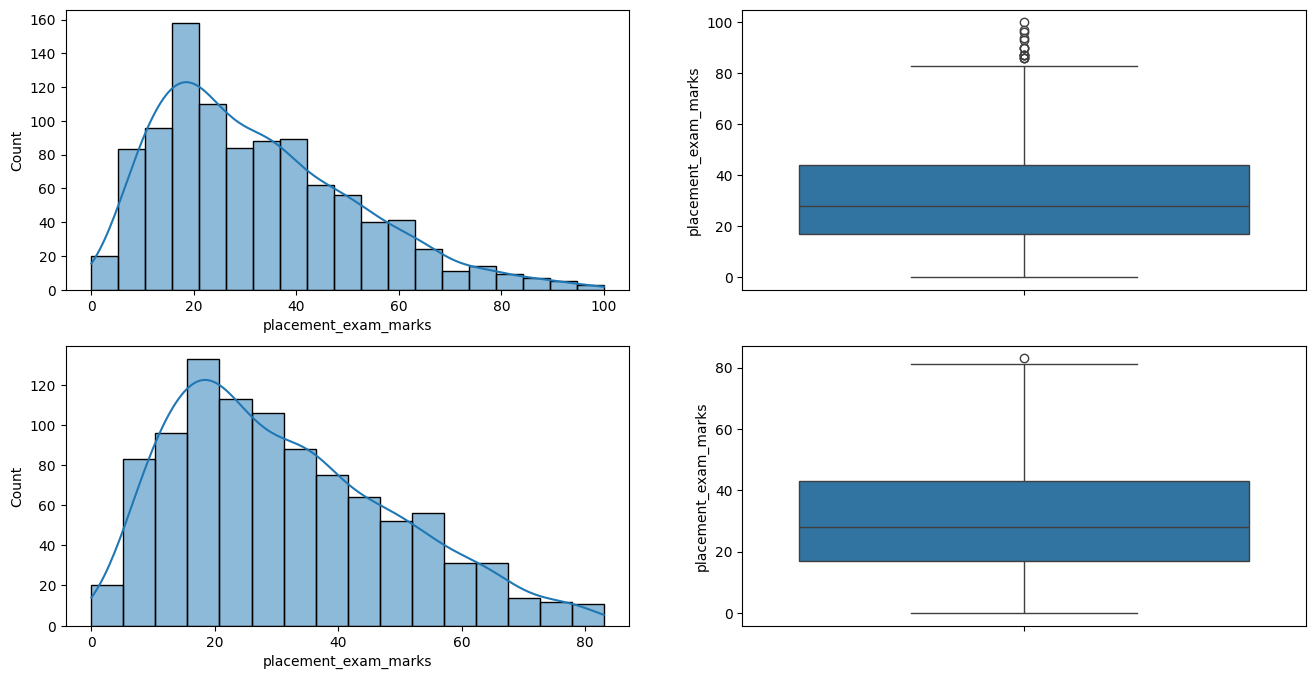

In [135]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(neww_df['placement_exam_marks'],kde=True)

plt.subplot(2,2,4)
sns.boxplot(neww_df['placement_exam_marks'])

plt.show()

In [137]:
neww_df.shape

(985, 4)

In [139]:
#______CAPPING_______
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    )
)

In [141]:
new_df_cap.shape

(1000, 4)

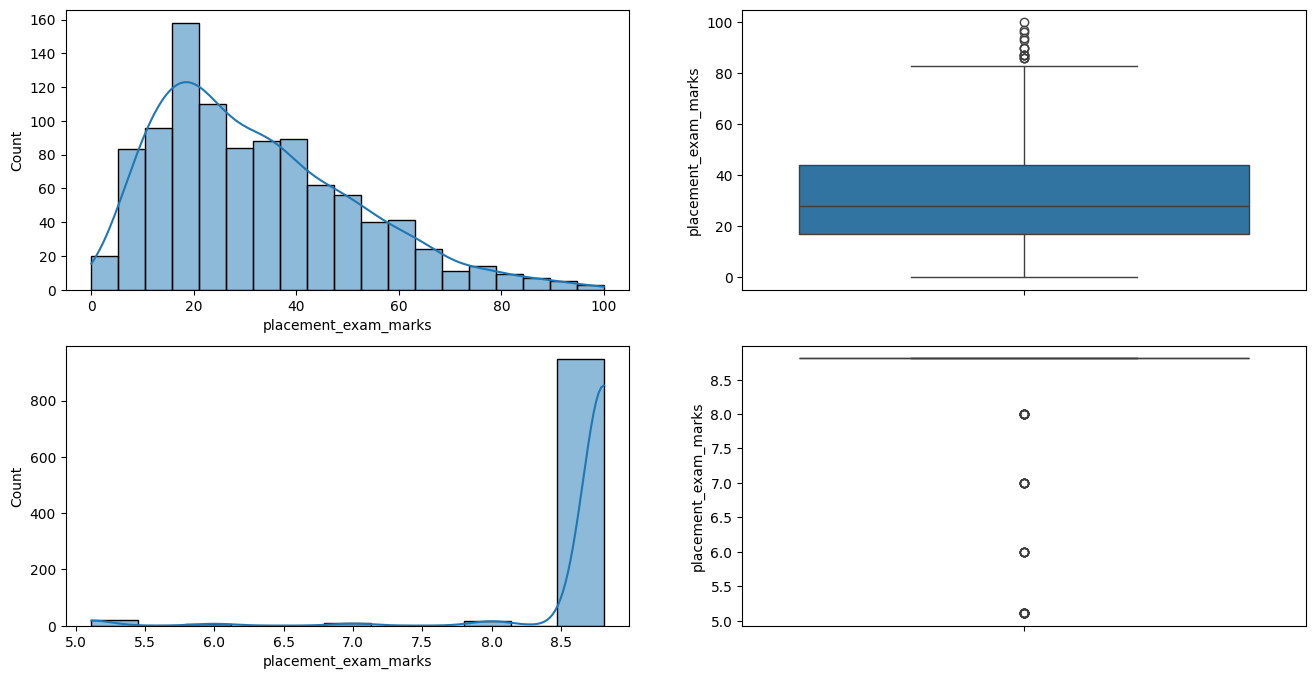

In [145]:
# Comparing

plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
sns.boxplot(df['placement_exam_marks'])

plt.subplot(2,2,3)
sns.histplot(new_df_cap['placement_exam_marks'],kde=True)

plt.subplot(2,2,4)
sns.boxplot(new_df_cap['placement_exam_marks'])

plt.show()

**WINSORIZATION**

In [148]:
df = pd.read_csv('weight-height.csv')

In [150]:
df.sample(5)

,Gender,Height,Weight
2817,Male,67.524639,174.399730
3618,Male,67.904701,176.632479
7691,Female,59.242568,114.740945
3546,Male,66.089450,166.506641
210,Male,68.589270,173.595796


In [152]:
df.shape

(10000, 3)

<Axes: xlabel='Height', ylabel='Count'>

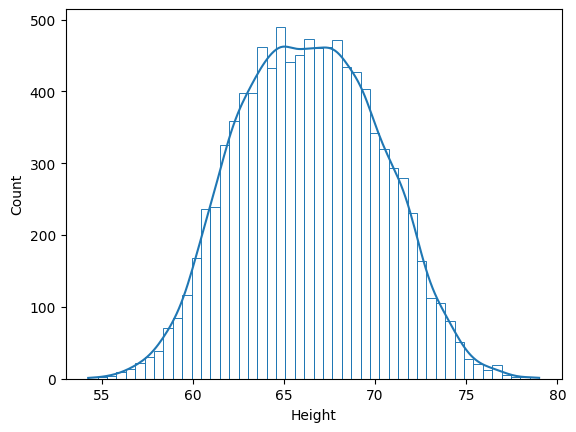

In [158]:
sns.histplot(df['Height'],kde=True,fill=False)

<Axes: ylabel='Height'>

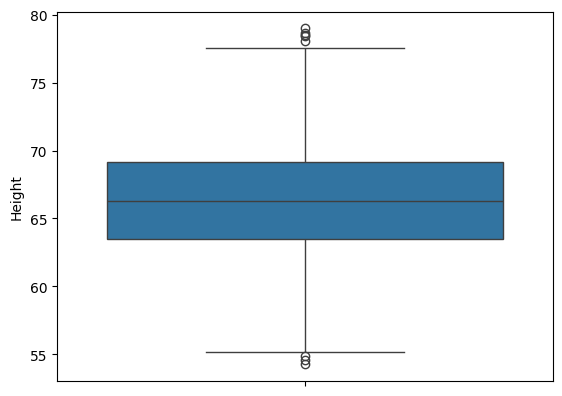

In [160]:
sns.boxplot(df['Height'])

In [162]:
upper_limit = df['Height'].quantile(0.99)
upper_limit

74.7857900583366

In [164]:
lower_limit = df['Height'].quantile(0.01)
lower_limit

58.13441158671655

In [170]:
new_df = df[(df['Height'] <= 74.78) & (df['Height'] >= 58.13)]
df['Height'].describe()

count    10000.000000
mean        66.367560
std          3.847528
min         54.263133
25%         63.505620
50%         66.318070
75%         69.174262
max         78.998742
Name: Height, dtype: float64

In [172]:
new_df['Height'].describe()

count    9799.000000
mean       66.363507
std         3.644267
min        58.134496
25%        63.577147
50%        66.317899
75%        69.119859
max        74.767447
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

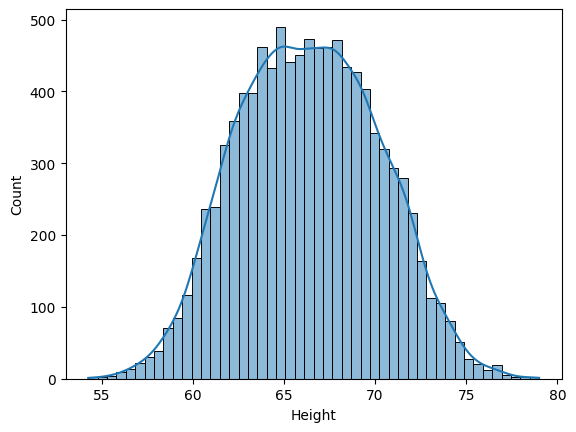

In [174]:
sns.histplot(df['Height'],kde=True)

In [176]:
# Capping --> Winsorization
df['Height'] = np.where(df['Height'] >= upper_limit,
        upper_limit,
        np.where(df['Height'] <= lower_limit,
        lower_limit,
        df['Height']))

In [178]:
df.shape

(10000, 3)

In [182]:
df['Height'].describe()

count    10000.000000
mean        66.366281
std          3.795717
min         58.134412
25%         63.505620
50%         66.318070
75%         69.174262
max         74.785790
Name: Height, dtype: float64

<Axes: xlabel='Height', ylabel='Count'>

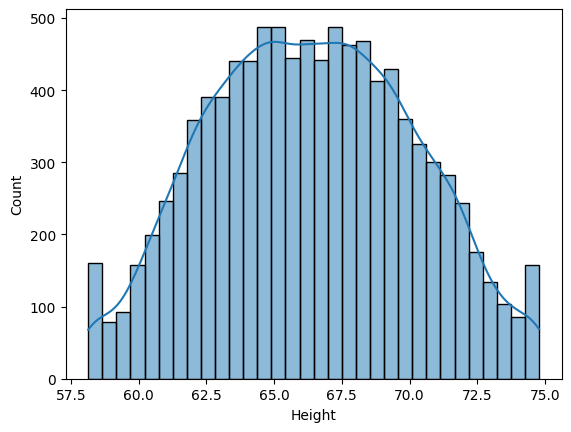

In [184]:
sns.histplot(df['Height'],kde=True)

<Axes: ylabel='Height'>

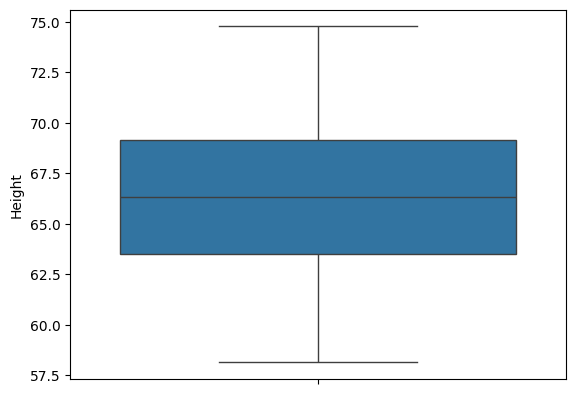

In [186]:
sns.boxplot(df['Height'])